To demonstrate ``AAPredPlot().scatter()``, we obtain the per-sample scores of two predictors (here two random-forest fits with different seeds):

In [1]:
import aaanalysis as aa
aa.options["verbose"] = False  # Disable verbosity

# DOM_GSEC example dataset + its feature set (see [Breimann25]_)
df_seq = aa.load_dataset(name="DOM_GSEC")
labels = df_seq["label"].to_list()
df_feat = aa.load_features(name="DOM_GSEC").head(20)

# Build the CPP feature matrix
sf = aa.SequenceFeature()
df_parts = sf.get_df_parts(df_seq=df_seq)
X = sf.feature_matrix(features=df_feat["feature"], df_parts=df_parts)

aapred = aa.AAPred(random_state=0)
aapred.fit(X, labels)
pred_1, _ = aapred.predict_proba(X)
aapred = aa.AAPred(random_state=1)
aapred.fit(X, labels)
pred_2, _ = aapred.predict_proba(X)

/Users/stephanbreimann/Programming/1Packages/wt-prediction-class/aaanalysis/feature_engineering/_backend/cpp_run.py:164: UserWarning: CPP is using the Python kernel fallback — the compiled Cython extension is not available in this install. Output is bit-exact with the Cython path but ~2x slower. Reinstall via `pip install --force-reinstall aaanalysis` to fetch a prebuilt wheel.
  warnings.warn(


The scatter compares the two predictors sample by sample, colored by class, with the ``y = x`` agreement line:

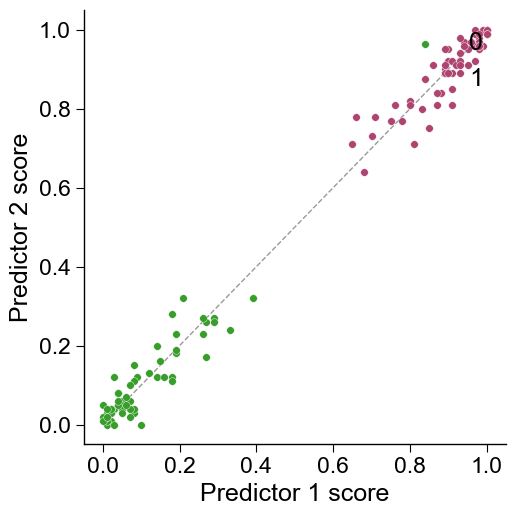

In [2]:
import matplotlib.pyplot as plt
aa.plot_settings()
aapred_plot = aa.AAPredPlot()
aapred_plot.scatter(pred_1, pred_2, labels=labels,
                    xlabel="Predictor 1 score", ylabel="Predictor 2 score")
plt.tight_layout()
plt.show()